In [35]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io

import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [36]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_SDF'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [37]:
nbatch = 10

In [38]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)



In [39]:
num_epochs    =50
patience      =10    # How long to wait after last time validation loss improved
LR            =0.0001

# Model name
model_name    ="U-Net"
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

#number_of_filters = [64, 128, 256, 512, 1024]
number_of_filters = [32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
#optimizer = RMSprop(learning_rate=LR)
optimizer = Adam(learning_rate=LR)
#optimizer = SGD(learning_rate=LR, momentum=0.9)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [40]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def biLSTM(x,units=128):
    _, h, w, c = x.shape #Flatten spatial dimensions for LSTM
    x_reshaped = layers.Reshape((h*w, c))(x)
    x_bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(x_reshaped) 
    x_bilstm = layers.Reshape((h, w, units*2))(x_bilstm)
    return x_bilstm

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [41]:
# number_of_filters = [32,64,128,256,512]
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])

    conv5 = conv_block(number_of_filters[4],down_block4)
   
 
    up6=decoder(conv5,conv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,conv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,conv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,conv1,number_of_filters[0],transpose='yes')

    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae'] )

    return model  

In [42]:
M=make_model()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,763,460 (29.62 MB)

 Trainable params: 7,761,540 (29.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [43]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

Starting trainig
Epoch 1/50


I0000 00:00:1749149866.499588   16255 service.cc:152] XLA service 0x7fd8fc0038a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749149866.499604   16255 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-06-05 14:57:46.704817: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749149867.674912   16255 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-05 14:57:50.272371: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.57 = (f32[10,32,64,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,1,64,256]{3,2,1,0} %bitcast.12565, f32[32,1,3,3]{3,2,1,0} %bitcast.11628, f32[32]{0} %bitcast.13973), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

  1/140 ━━━━━━━━━━━━━━━━━━━━ 54:02 23s/step - loss: 0.0660 - mae: 0.2113

I0000 00:00:1749149884.882007   16255 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0209 - mae: 0.1006

2025-06-05 14:58:19.945370: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.65 = (f32[10,512,4,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,256,4,16]{3,2,1,0} %bitcast.1588, f32[512,256,3,3]{3,2,1,0} %bitcast.1595, f32[512]{0} %bitcast.1597), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-Net_1/conv2d_8_1/convolution" source_file="/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-06-05 14:58:20.226259: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc

140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - loss: 0.0209 - mae: 0.1003 - val_loss: 0.0160 - val_mae: 0.0972
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0029 - mae: 0.0343 - val_loss: 0.0116 - val_mae: 0.0726
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - loss: 0.0017 - mae: 0.0250 - val_loss: 0.0110 - val_mae: 0.0672
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0014 - mae: 0.0218 - val_loss: 0.0091 - val_mae: 0.0580
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0011 - mae: 0.0196 - val_loss: 0.0046 - val_mae: 0.0390
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 9.5014e-04 - mae: 0.0181 - val_loss: 9.2591e-04 - val_mae: 0.0193
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 8.6808e-04 - mae: 0.0169 - val_loss: 0.0018 - val_mae: 0.0243
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 8.1605e-04 - mae: 0.0162 - val_loss: 0.0018 - val_mae: 0.0248
Epoch 9/50
140/140 ━━━━━━━━

In [44]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0047 - mae: 0.0392
Evaluation results:
loss: 0.0045
compile_metrics: 0.0386


In [45]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━

In [46]:
def plotting():
    N = random.randint(0, len(xtrue)-1)
    M = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[M][N][:,:,i]- ypred[M][N][:,:,i]))

            axes[i,0].imshow(ypred[M][N][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[M][N][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

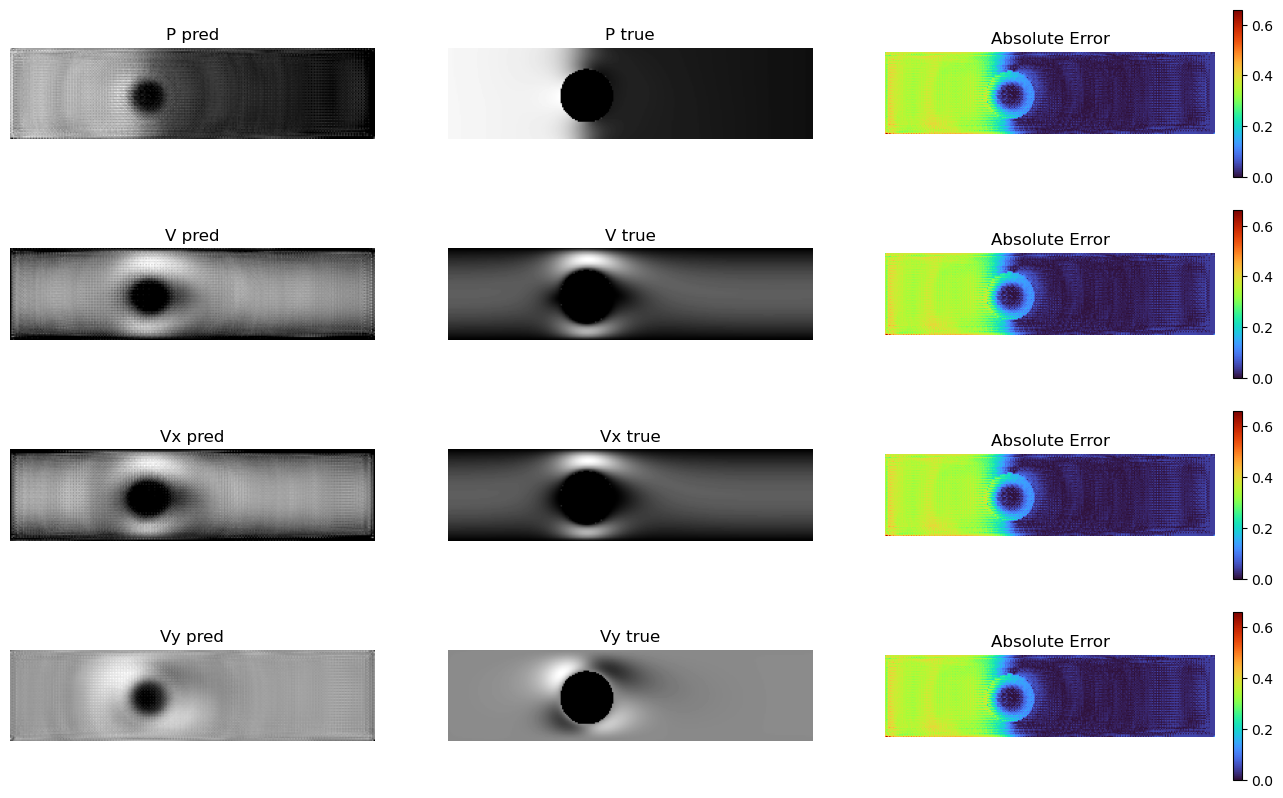

In [65]:
plotting()

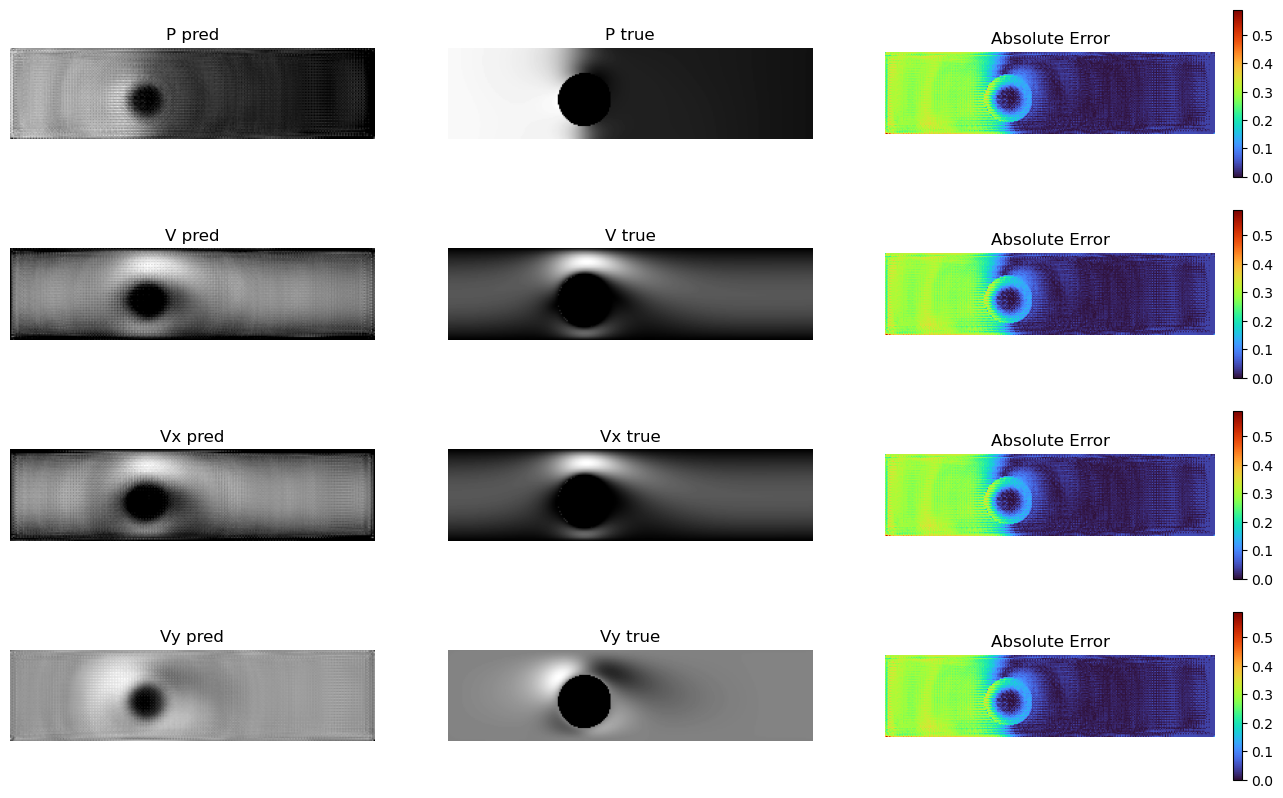

In [74]:
plotting()

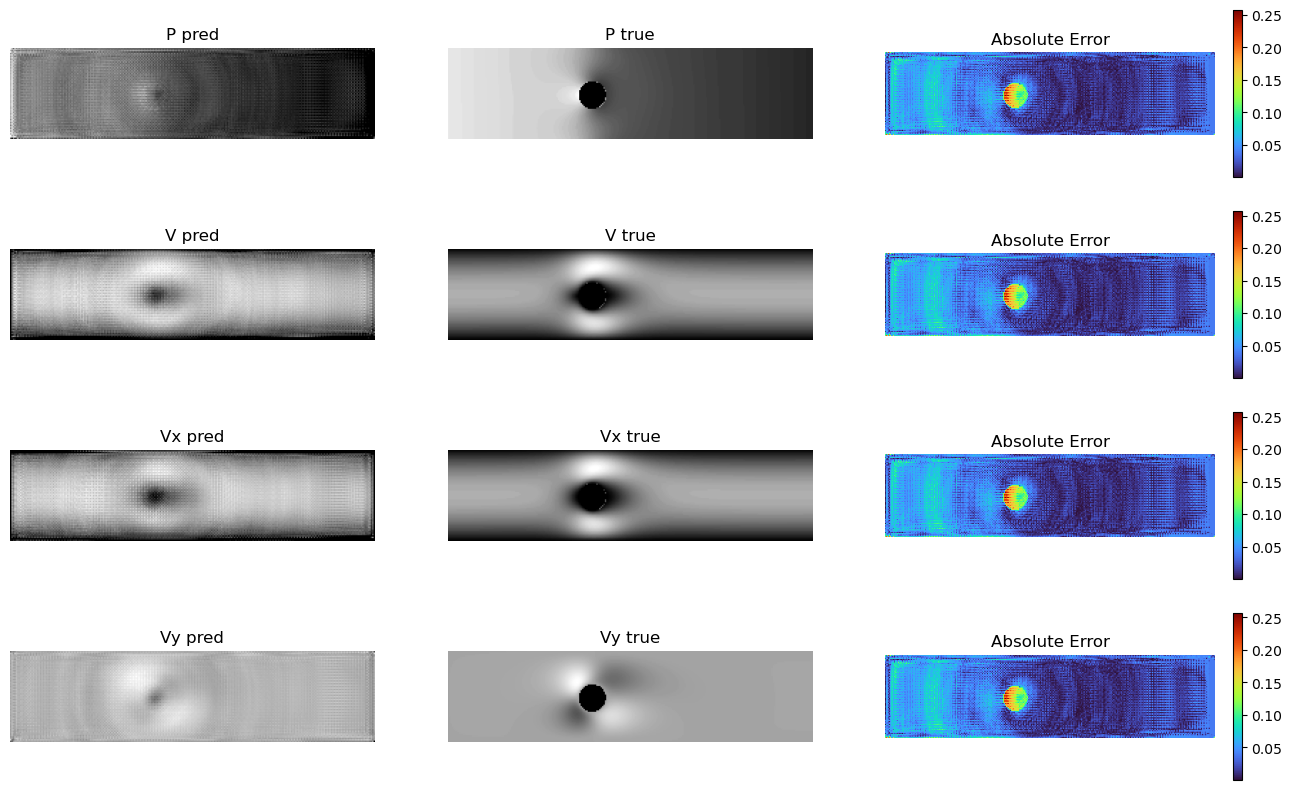

In [82]:
plotting()

In [57]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

2025-06-05 15:04:50.873468: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [58]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [59]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

p: MSE = 0.0079, MAE = 0.0524
v: MSE = 0.0026, MAE = 0.0338
vx: MSE = 0.0025, MAE = 0.0338
vy: MSE = 0.0049, MAE = 0.0344


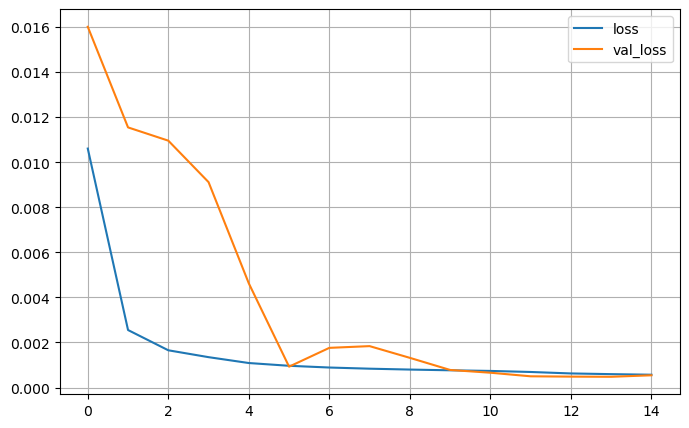

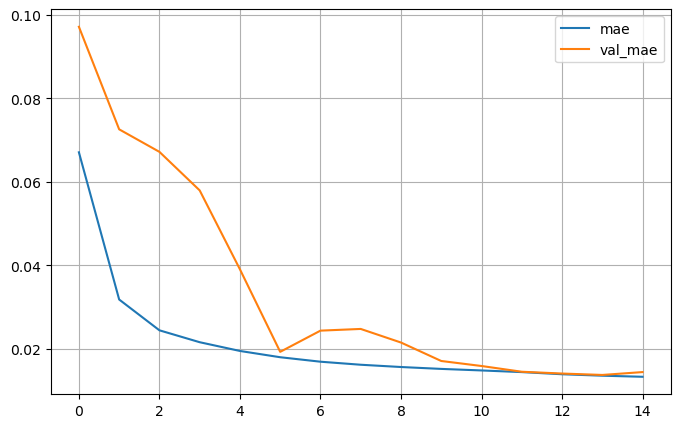

In [60]:
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.grid(True)
plt.show()

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.grid(True)
plt.show() 